# NYC Yellow Taxi: my three visualizations
**Member 2: Sai Shivananda Gunda · DATA 230 group project**

**Group problem statement:** How do time of day, day of week and pickup location shape fares and tips, and can we predict a high-fare trip using only what is known at pickup?

**My contribution — EDA Lead A:** Explore pickup-time and location patterns, test whether passenger groups have different trip-length distributions, and connect these patterns to the fare question. The three major Python figures reproduce my Tableau visuals. Supporting summary tables compare fares, high-fare shares and recorded credit-card tips using the same time, location and passenger groups.

This notebook creates your **weekday/hour heatmap**, **taxi-zone choropleth**, and **passenger-group versus trip-length grouped bars**. It includes a question, measured insight and EDA decision for every plot, plus a RAPIDS/cuDF experiment.

**Input:** Download the four raw monthly files directly from [Kaggle: NYC Yellow Taxi Trip Data](https://www.kaggle.com/datasets/elemento/nyc-yellow-taxi-trip-data), covering **January 2015 and January–March 2016**. No multi-gigabyte upload is needed. The notebook reproducibly selects approximately **25% of raw rows**, cleans them in chunks and analyses **every retained row**, with no second sample. It also supports an existing cleaned local file through `DATA_SOURCE='local'`.

**Comparison with Tableau:** The original Member 1 cleaning notebook and sampling seed were not supplied. This Kaggle route creates a new, audited sample rather than claiming to reconstruct the original **11,496,446-row** file exactly. Your original Tableau images are embedded as references; Python outputs are calculated from the newly downloaded data. Slide-value comparisons reveal any differences. A CUDA GPU is required for actual RAPIDS timings.

| Major figure | EDA question | Connection to the problem statement |
|---|---|---|
| 1. Weekday/hour heatmap | When are pickups busiest? | Identifies time patterns; the supporting fare table checks whether busy periods also have higher fares or card-tip percentages. |
| 2. Pickup-zone choropleth | Where do pickups concentrate? | Identifies spatial differences; the supporting zone table compares fares and high-fare rates at those same pickup locations. |
| 3. Passenger-group/trip-length bars | Do larger groups take longer trips? | Tests a possible indirect fare relationship; the supporting group table directly checks fare patterns. Trip distance is only used for EDA, because it is unknown at pickup. |

## 1. Run it in Google Colab
1. Open this notebook in Colab. No trip-data upload is required.
2. Leave `DATA_SOURCE='kaggle'` and run the cells in order. The acquisition cell downloads only the four required CSV files using Kaggle's official `kagglehub` package.
3. The raw files total about 7.4 GB before compression. Downloading takes time and disk space, but chunk processing avoids loading all raw trips into RAM. A cached cleaned Parquet file is reused when its preparation settings match.
4. `RUN_GPU=False` allows the full CPU EDA and exports to finish on any runtime. For your RAPIDS contribution, select **Runtime → Change runtime type → GPU**, set `RUN_GPU=True` and run again. GPU timings are not fabricated when a GPU is unavailable.
5. If Kaggle requests authentication, add your token to **Colab Secrets** as `KAGGLE_API_TOKEN` and allow this notebook access. Never paste a token in a cell or commit it to GitHub. The public download is attempted without authentication first.
6. Download `member2_eda_outputs.zip` from the final section. Save the executed notebook using **File → Download → Download .ipynb** so GitHub shows the results.

The map uses official TLC taxi-zone boundaries. Latitude/longitude rows are matched to polygons in chunks without taking another sample. Time and group-size plots retain valid rows even when their pickup cannot be mapped.

In [ ]:
from pathlib import Path

# Usually this is the only cell you need to edit.
DATA_SOURCE = 'kaggle'  # 'kaggle' downloads automatically; 'local' uses DATA_PATH.
KAGGLE_HANDLE = 'elemento/nyc-yellow-taxi-trip-data'
KAGGLE_RAW_DIR = Path('data/raw/kaggle').resolve()
DATA_PATH = 'data/processed/yellow_taxi_kaggle_clean.parquet'
SAMPLE_FRACTION = 0.25
SAMPLE_SEED = 42
RAW_CHUNK_SIZE = 200_000
NYC_LONGITUDE_RANGE = (-74.30, -73.65)
NYC_LATITUDE_RANGE = (40.50, 40.95)
USE_GOOGLE_DRIVE = False
# Example Drive path: '/content/drive/MyDrive/NYC_Taxi/yellow_taxi_clean.parquet'

RUN_GPU = True
INSTALL_MISSING_PACKAGES = True
CUDA_WHEEL = 'cu12'  # Used only if cuDF is absent; must match the installed CUDA toolkit.

OUTPUT_DIR = Path('member2_eda_outputs').resolve()
EXPECTED_PROJECT_ROWS = 11_496_446
PROJECT_MONTHS = ('2015-01', '2016-01', '2016-02', '2016-03')
MAP_CHUNK_SIZE = 200_000
BENCHMARK_REPEATS = 3
HIGH_FARE_CUTOFF = None  # Set to the team's agreed training-derived dollar cutoff, if available.
HIGH_FARE_QUANTILE = 0.80
REFERENCE_MONTH_CODES = (201501, 201601, 201602)  # March 2016 is the planned test period.
MIN_COMPARISON_ROWS = 100

TLC_DATA_URL = 'https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page'
TAXI_ZONES_URL = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip'
ZONE_ARCHIVE = OUTPUT_DIR / 'support' / 'taxi_zones.zip'

In [ ]:
import importlib.util
import subprocess
import sys
import shutil

required_packages = {
    'pandas': 'pandas>=2.2,<3', 'numpy': 'numpy',
    'matplotlib': 'matplotlib', 'seaborn': 'seaborn',
    'pyarrow': 'pyarrow', 'geopandas': 'geopandas>=1.0',
    'shapely': 'shapely>=2.0',
}
if DATA_SOURCE == 'kaggle':
    required_packages.update({'kagglehub': 'kagglehub>=1.0', 'duckdb': 'duckdb>=1.1'})
missing = [spec for name, spec in required_packages.items()
           if importlib.util.find_spec(name) is None]
if missing and INSTALL_MISSING_PACKAGES:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
elif missing:
    raise RuntimeError('Install the missing packages: ' + ', '.join(missing))

GPU_DETECTED = False
GPU_INFO_TEXT = ''
if shutil.which('nvidia-smi'):
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    GPU_INFO_TEXT = result.stdout
    GPU_DETECTED = result.returncode == 0
    print(result.stdout or result.stderr)
else:
    print('No NVIDIA GPU was detected. The three CPU charts can still run.')

# Current Colab environments often already include cuDF. Install only when needed.
if RUN_GPU and GPU_DETECTED and importlib.util.find_spec('cudf') is None:
    if not INSTALL_MISSING_PACKAGES:
        raise RuntimeError('cuDF is missing. Enable package installation or follow the linked RAPIDS setup guide.')
    if CUDA_WHEEL not in ('cu12', 'cu13'):
        raise ValueError('CUDA_WHEEL must be cu12 or cu13, matching your installed CUDA toolkit.')
    cupy_package = 'cupy-cuda12x' if CUDA_WHEEL == 'cu12' else 'cupy-cuda13x'
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           f'cudf-{CUDA_WHEEL}', cupy_package,
                           '--extra-index-url=https://pypi.nvidia.com'])

if RUN_GPU and not GPU_DETECTED:
    print('GPU experiment is NOT executed yet. Select a GPU runtime before running section 7.')

Thu Oct  8 00:15:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import gc
import hashlib
import json
import platform
import re
import time
import zipfile
from datetime import datetime, timezone
from urllib.request import urlopen

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display, Markdown

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'figures').mkdir(exist_ok=True)
(OUTPUT_DIR / 'tables').mkdir(exist_ok=True)
(OUTPUT_DIR / 'support').mkdir(exist_ok=True)

# Remove only outputs owned by this notebook that can otherwise survive a rerun.
for name in ('eda_1_weekday_hour_heatmap.png', 'eda_2_pickup_zone_choropleth.png',
             'eda_3_passenger_group_trip_length.png'):
    (OUTPUT_DIR / 'figures' / name).unlink(missing_ok=True)
for name in ('10_cpu_gpu_benchmark.csv', '14_fare_target_summary.csv',
             '15_time_fare_tip_summary.csv', '16_zone_fare_summary.csv',
             '17_passenger_group_fare_summary.csv'):
    (OUTPUT_DIR / 'tables' / name).unlink(missing_ok=True)

sns.set_theme(style='white', font_scale=1.05)
plt.rcParams.update({'figure.facecolor': 'white', 'axes.titleweight': 'bold',
                     'savefig.facecolor': 'white', 'font.family': 'DejaVu Sans'})
WEEKDAYS = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
PASSENGER_LABELS = ['1 passenger', '2 passengers', '3–6 passengers']
DISTANCE_LABELS = ['Short (<2 miles)', 'Medium (2–<5 miles)', 'Long (5+ miles)']
INSIGHTS = []
GPU_STATUS = 'NOT RUN'

print('Python:', platform.python_version())
print('pandas:', pd.__version__, '| GeoPandas:', gpd.__version__)

def save_figure(fig, filename):
    destination = OUTPUT_DIR / 'figures' / filename
    fig.savefig(destination, dpi=220, bbox_inches='tight')
    print('Saved:', destination)

def record_insight(plot, question, insight, decision):
    INSIGHTS.append({'Plot': plot, 'Question': question, 'Measured insight': insight,
                     'EDA decision': decision})
    display(Markdown(f'**Insight:** {insight}\n\n**EDA decision:** {decision}'))

Python: 3.13.15
pandas: 2.2.3 | GeoPandas: 1.2.0


## 2A. Download from Kaggle and prepare the analysis sample

This cell downloads the four specified files directly into the runtime. It reads one CSV chunk at a time, reproducibly selects about 25% of its rows, applies simple validity rules, writes retained trips to Parquet and removes exact duplicates across the complete retained sample using a disk-backed query.

**Preparation rules:** Parse timestamps and numeric fields; require finite essential values; keep pickup dates in the four project months; require dropoff after pickup, duration 1–180 minutes, positive distance up to 100 miles, positive fare up to $500, integer passengers 1–6, speed up to 80 mph and valid payment/rate codes. Pickup and dropoff must fall within the configurable analysis bounding box. Require nonnegative recorded tips and available taxes/tolls/surcharges. Valid airport trips within those limits remain. Every rule's sequential removal count is exported.

These are transparent reconstruction rules, not a claim that Member 1 used exactly the same conditions. The bounding box is an approximate analysis region, not a NYC administrative polygon. Keep the configuration and output audit with your contribution.

In [ ]:
kaggle_provenance = {}
if DATA_SOURCE not in ('kaggle', 'local'):
    raise ValueError("DATA_SOURCE must be 'kaggle' or 'local'.")
if DATA_SOURCE == 'kaggle':
    import kagglehub
    import duckdb
    import pyarrow as pa

    if not 0 < SAMPLE_FRACTION <= 1:
        raise ValueError('SAMPLE_FRACTION must be between 0 and 1.')
    if RAW_CHUNK_SIZE < 1:
        raise ValueError('RAW_CHUNK_SIZE must be positive.')
    processed_path = Path(DATA_PATH).expanduser().resolve()
    processed_path.parent.mkdir(parents=True, exist_ok=True)
    preparation_path = processed_path.with_suffix('.preparation.json')
    preparation_settings = {
        'dataset_handle': KAGGLE_HANDLE, 'months': list(PROJECT_MONTHS),
        'sampling': 'seeded Bernoulli selection of raw rows, before cleaning',
        'fraction': SAMPLE_FRACTION, 'seed': SAMPLE_SEED,
        'csv_chunk_size': RAW_CHUNK_SIZE,
        'longitude_bounds': list(NYC_LONGITUDE_RANGE),
        'latitude_bounds': list(NYC_LATITUDE_RANGE), 'rules_version': 1,
    }
    cached = json.loads(preparation_path.read_text()) if preparation_path.exists() else {}
    if processed_path.exists() and cached.get('settings') == preparation_settings:
        kaggle_provenance = cached
        print(f'Reusing prepared sample: {processed_path.name}, {cached["retained_rows"]:,} rows.')
    else:
        raw_names = [f'yellow_tripdata_{month}.csv' for month in PROJECT_MONTHS]
        raw_aliases = {
            'vendorid': 'vendor_id', 'tpeppickupdatetime': 'pickup_datetime',
            'tpepdropoffdatetime': 'dropoff_datetime', 'passengercount': 'passenger_count',
            'tripdistance': 'trip_distance', 'pickuplongitude': 'pickup_longitude',
            'pickuplatitude': 'pickup_latitude', 'dropofflongitude': 'dropoff_longitude',
            'dropofflatitude': 'dropoff_latitude', 'ratecodeid': 'rate_code_id',
            'storeandfwdflag': 'store_and_fwd_flag', 'paymenttype': 'payment_type',
            'fareamount': 'fare_amount', 'extra': 'extra', 'mtatax': 'mta_tax',
            'tipamount': 'tip_amount', 'tollsamount': 'tolls_amount',
            'improvementsurcharge': 'improvement_surcharge', 'totalamount': 'total_amount',
        }
        required_raw = ['pickup_datetime', 'dropoff_datetime', 'passenger_count', 'trip_distance',
                        'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
                        'fare_amount', 'tip_amount', 'payment_type']
        intermediate = processed_path.with_suffix('.before_dedup.parquet')
        intermediate.unlink(missing_ok=True)
        writer = None
        rule_counts = {}
        file_rows = []
        total_raw = total_sampled = total_retained = 0
        try:
            for file_number, filename in enumerate(raw_names):
                print('Downloading or reusing:', filename, flush=True)
                folder = KAGGLE_RAW_DIR / filename.removesuffix('.csv')
                try:
                    downloaded = Path(kagglehub.dataset_download(
                        KAGGLE_HANDLE, path=filename, output_dir=str(folder)))
                except Exception as exc:
                    raise RuntimeError(
                        'Kaggle download failed. Check internet access. If Kaggle requests authentication, '
                        'use a Colab Secret named KAGGLE_API_TOKEN; do not place credentials in notebook cells.'
                    ) from exc
                raw_path = downloaded if downloaded.is_file() else downloaded / filename
                if not raw_path.exists():
                    candidates = list(folder.rglob(filename))
                    if len(candidates) != 1:
                        raise FileNotFoundError(f'Downloaded CSV could not be resolved: {filename}')
                    raw_path = candidates[0]
                rng = np.random.default_rng(np.random.SeedSequence([SAMPLE_SEED, file_number]))
                raw_count = sampled_count = kept_count = 0
                for chunk_number, chunk in enumerate(pd.read_csv(raw_path, chunksize=RAW_CHUNK_SIZE,
                                                                low_memory=False), start=1):
                    raw_count += len(chunk)
                    chunk = chunk.loc[rng.random(len(chunk)) < SAMPLE_FRACTION].copy()
                    sampled_count += len(chunk)
                    chunk.columns = [raw_aliases.get(re.sub(r'[^a-z0-9]', '', str(c).lower()),
                                                     re.sub(r'[^a-z0-9]', '', str(c).lower()))
                                     for c in chunk.columns]
                    absent = [c for c in required_raw if c not in chunk]
                    if absent:
                        raise ValueError(f'{filename} is missing required fields: {absent}')
                    for column in chunk:
                        if column.endswith('_datetime'):
                            chunk[column] = pd.to_datetime(chunk[column], errors='coerce',
                                                           format='%Y-%m-%d %H:%M:%S')
                        elif column == 'store_and_fwd_flag':
                            chunk[column] = chunk[column].astype('string')
                        else:
                            chunk[column] = pd.to_numeric(chunk[column], errors='coerce').astype('float64')
                    duration = (chunk['dropoff_datetime'] - chunk['pickup_datetime']).dt.total_seconds() / 60
                    finite_required = np.isfinite(chunk[[c for c in required_raw if not c.endswith('_datetime')]]).all(axis=1)
                    gps_valid = pd.Series(True, index=chunk.index)
                    for column in ('pickup_longitude', 'dropoff_longitude'):
                        gps_valid &= chunk[column].between(*NYC_LONGITUDE_RANGE)
                    for column in ('pickup_latitude', 'dropoff_latitude'):
                        gps_valid &= chunk[column].between(*NYC_LATITUDE_RANGE)
                    rules = [
                        ('Missing or nonfinite essential numeric values', finite_required),
                        ('Invalid timestamps or pickup outside project months',
                         chunk['pickup_datetime'].notna() & chunk['dropoff_datetime'].notna()
                         & chunk['pickup_datetime'].dt.strftime('%Y-%m').isin(PROJECT_MONTHS)),
                        ('Dropoff not after pickup', duration.gt(0)),
                        ('Duration outside 1–180 minutes', duration.between(1, 180)),
                        ('Pickup/dropoff outside the configured analysis box', gps_valid),
                        ('Distance outside (0, 100] miles', chunk['trip_distance'].gt(0) & chunk['trip_distance'].le(100)),
                        ('Fare outside (0, 500] dollars', chunk['fare_amount'].gt(0) & chunk['fare_amount'].le(500)),
                        ('Passengers outside integer 1–6', chunk['passenger_count'].between(1, 6)
                         & chunk['passenger_count'].mod(1).eq(0)),
                        ('Recorded average speed over 80 mph', (chunk['trip_distance'] / (duration / 60)).le(80)),
                        ('Invalid payment code', chunk['payment_type'].isin(range(1, 7))),
                    ]
                    if 'rate_code_id' in chunk:
                        rules.append(('Invalid rate code', chunk['rate_code_id'].isin(range(1, 7))))
                    monetary = [c for c in ('tip_amount', 'extra', 'mta_tax', 'tolls_amount',
                                             'improvement_surcharge', 'total_amount') if c in chunk]
                    rules.append(('Missing, negative or nonfinite recorded money values',
                                  (np.isfinite(chunk[monetary]) & chunk[monetary].ge(0)).all(axis=1)))
                    keep = pd.Series(True, index=chunk.index)
                    for label, valid in rules:
                        valid = valid.fillna(False)
                        removed = int((keep & ~valid).sum())
                        rule_counts[label] = rule_counts.get(label, 0) + removed
                        keep &= valid
                    cleaned_chunk = chunk.loc[keep]
                    kept_count += len(cleaned_chunk)
                    if len(cleaned_chunk):
                        table = pa.Table.from_pandas(cleaned_chunk, preserve_index=False)
                        if writer is None:
                            writer = pq.ParquetWriter(intermediate, table.schema, compression='snappy')
                        writer.write_table(table.cast(writer.schema))
                    if chunk_number == 1 or chunk_number % 10 == 0:
                        print(f'{filename}: read {raw_count:,}, selected {sampled_count:,}, valid {kept_count:,}', flush=True)
                total_raw += raw_count
                total_sampled += sampled_count
                total_retained += kept_count
                file_rows.append({'source_file': filename, 'raw_rows': raw_count,
                                  'sampled_rows': sampled_count, 'valid_rows_before_dedup': kept_count,
                                  'raw_file_bytes': raw_path.stat().st_size})
        finally:
            if writer is not None:
                writer.close()
        if total_retained == 0:
            raise ValueError('No rows survived preparation. Inspect the source schema and audit rules.')
        print('Removing exact duplicates across the full selected sample...', flush=True)
        connection = duckdb.connect()
        try:
            connection.execute("SET memory_limit='1GB'")
            connection.execute('SET threads=2')
            # Disk-backed global DISTINCT uses all standardized source columns, not just chart fields.
            unique_rows = connection.from_parquet(str(intermediate)).distinct()
            completed = processed_path.with_suffix('.ready.parquet')
            completed.unlink(missing_ok=True)
            unique_rows.write_parquet(str(completed), compression='snappy')
            final_rows = pq.ParquetFile(completed).metadata.num_rows
            completed.replace(processed_path)
        finally:
            connection.close()
        duplicate_rows = total_retained - final_rows
        rule_counts['Exact duplicates in the full retained sample'] = duplicate_rows
        kaggle_provenance = {'settings': preparation_settings, 'source_files': file_rows,
                             'raw_rows': total_raw, 'sampled_rows': total_sampled,
                             'valid_rows_before_dedup': total_retained, 'retained_rows': final_rows,
                             'removed_by_rule_in_order': rule_counts,
                             'prepared_at_utc': datetime.now(timezone.utc).isoformat(),
                             'comparison_note': 'New sample and explicit reconstruction rules; not guaranteed to match Member 1.'}
        preparation_path.write_text(json.dumps(kaggle_provenance, indent=2), encoding='utf-8')
        intermediate.unlink(missing_ok=True)
        print(f'Prepared {final_rows:,} rows from {total_raw:,} raw trips; exact duplicates removed: {duplicate_rows:,}.')
    pd.DataFrame(kaggle_provenance['source_files']).to_csv(
        OUTPUT_DIR / 'tables' / '00_kaggle_source_coverage.csv', index=False)
    preparation_audit = pd.DataFrame(list(kaggle_provenance['removed_by_rule_in_order'].items()),
                                      columns=['Sequential removal rule', 'Rows removed'])
    display(preparation_audit)
    preparation_audit.to_csv(OUTPUT_DIR / 'tables' / '00_kaggle_preparation_audit.csv', index=False)
    (OUTPUT_DIR / 'kaggle_preparation.json').write_text(json.dumps(kaggle_provenance, indent=2), encoding='utf-8')
else:
    print('Using the existing cleaned local file; Kaggle download and preparation are disabled.')

100%|██████████| 504M/504M [00:31<00:00, 16.8MB/s]

Extracting zip of yellow_tripdata_2015-01.csv...


yellow_tripdata_2015-01.csv: read 200,000, selected 50,164, valid 48,720
yellow_tripdata_2015-01.csv: read 2,000,000, selected 500,126, valid 485,264
yellow_tripdata_2015-01.csv: read 4,000,000, selected 1,000,711, valid 971,088
yellow_tripdata_2015-01.csv: read 6,000,000, selected 1,499,960, valid 1,455,750
yellow_tripdata_2015-01.csv: read 8,000,000, selected 2,000,112, valid 1,941,335
yellow_tripdata_2015-01.csv: read 10,000,000, selected 2,500,352, valid 2,426,696
yellow_tripdata_2015-01.csv: read 12,000,000, selected 3,000,220, valid 2,911,935


100%|██████████| 418M/418M [00:27<00:00, 16.2MB/s]

Extracting zip of yellow_tripdata_2016-01.csv...


...

Extracting zip of yellow_tripdata_2016-02.csv...


yellow_tripdata_2016-02.csv: read 200,000, selected 50,176, valid 48,968
yellow_tripdata_2016-02.csv: read 2,000,000, selected 499,924, valid 488,060
yellow_tripdata_2016-02.csv: read 4,000,000, selected 1,000,274, valid 974,483
yellow_tripdata_2016-02.csv: read 6,000,000, selected 1,500,601, valid 1,461,982
yellow_tripdata_2016-02.csv: read 8,000,000, selected 2,001,546, valid 1,948,207
yellow_tripdata_2016-02.csv: read 10,000,000, selected 2,501,385, valid 2,433,242
Using Colab cache for faster access to the 'nyc-yellow-taxi-trip-data' dataset.
yellow_tripdata_2016-03.csv: read 200,000, selected 49,963, valid 48,933
yellow_tripdata_2016-03.csv: read 2,000,000, selected 499,668, valid 487,030
yellow_tripdata_2016-03.csv: read 4,000,000, selected 999,708, valid 976,520
yellow_tripdata_2016-03.csv: read 6,000,000, selected 1,499,252, valid 1,463,524
yellow_tripdata_2016-03.csv: read 8,000,000, selected 1,999,924, valid 1,950,649
yellow_tripdata_2016-03.csv: read 10,000,000, selected 2,5

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Prepared 11,495,890 rows from 47,248,845 raw trips; exact duplicates removed: 0.


,Sequential removal rule,Rows removed
0,Missing or nonfinite essential numeric values,0
1,Invalid timestamps or pickup outside project m...,0
2,Dropoff not after pickup,12882
3,Duration outside 1–180 minutes,98163
4,Pickup/dropoff outside the configured analysis...,187717
5,"Distance outside (0, 100] miles",12088
6,"Fare outside (0, 500] dollars",3750
7,Passengers outside integer 1–6,1537
8,Recorded average speed over 80 mph,803
9,Invalid payment code,0


## 2. Read the full cleaned file and verify its scope

Only columns needed for these charts are loaded, which reduces memory use while retaining every input row. Date parts are recalculated from the pickup timestamp so weekday labels cannot be reversed by a different numeric coding.

This is EDA on the prepared Kaggle sample or the local cleaned output you chose. Missing or invalid values are counted below; chart-specific exclusions are documented instead of silently removing the same records from every chart.

In [ ]:
if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except ImportError as exc:
        raise RuntimeError('Google Drive mounting is available in Colab. For local Jupyter, set USE_GOOGLE_DRIVE=False.') from exc

input_path = Path(DATA_PATH).expanduser()
if not input_path.exists() and DATA_PATH == 'yellow_taxi_clean.parquet':
    candidates = [Path('yellow_taxi_clean_1.parquet'),
                  Path('data/processed/yellow_taxi_clean.parquet'),
                  Path('data/processed/yellow_taxi_clean_1.parquet')]
    input_path = next((p for p in candidates if p.exists()), input_path)
if not input_path.exists():
    raise FileNotFoundError(
        f'Cleaned file not found: {input_path}. Upload the full cleaned Parquet file, '
        'or set DATA_PATH to its actual local/Google Drive path. A chart image is not a trip dataset.'
    )

def column_key(value):
    return re.sub(r'[^a-z0-9]', '', str(value).lower())

ALIASES = {
    'pickup_datetime': ['tpeppickupdatetime', 'pickupdateTime'.lower(), 'lpeppickupdatetime'],
    'passenger_count': ['passengercount', 'passengers'],
    'trip_distance': ['tripdistance', 'distance'],
    'pickup_longitude': ['pickuplongitude', 'pickuplon', 'pickuplng'],
    'pickup_latitude': ['pickuplatitude', 'pickuplat'],
    'pickup_zone_id': ['pulocationid', 'pickuplocationid', 'pickupzoneid', 'pickupzone'],
    'fare_amount': ['fareamount', 'fare'],
    'tip_amount': ['tipamount', 'tip'],
    'payment_type': ['paymenttype'],
}

if input_path.suffix.lower() in ('.parquet', '.pq'):
    schema_columns = pq.ParquetFile(input_path).schema.names
elif input_path.suffix.lower() == '.csv':
    schema_columns = pd.read_csv(input_path, nrows=0).columns.tolist()
else:
    raise ValueError('Use a cleaned .parquet or .csv file. Parquet is recommended for the full sample.')

normalized_names = {column_key(c): c for c in schema_columns}
selected = {}
for canonical, aliases in ALIASES.items():
    for alias in aliases:
        if alias in normalized_names:
            selected[canonical] = normalized_names[alias]
            break

essential = ['pickup_datetime', 'passenger_count', 'trip_distance']
missing_columns = [c for c in essential if c not in selected]
has_coordinates = {'pickup_longitude', 'pickup_latitude'}.issubset(selected)
if missing_columns or not ('pickup_zone_id' in selected or has_coordinates):
    raise ValueError(f'Required columns are missing: {missing_columns}. The map also needs '
                     f'PULocationID or pickup longitude AND latitude. Available columns: {schema_columns}')

if input_path.suffix.lower() in ('.parquet', '.pq'):
    df = pd.read_parquet(input_path, columns=list(selected.values()))
else:
    df = pd.read_csv(input_path, usecols=list(selected.values()), low_memory=False)
df = df.rename(columns={original: canonical for canonical, original in selected.items()})
INPUT_ROWS = len(df)
print('Input file:', input_path.name)
print(f'Rows loaded: {INPUT_ROWS:,} | Original columns: {len(schema_columns)} | Selected: {len(df.columns)}')
display(pd.DataFrame({'Notebook field': list(selected), 'Original field': list(selected.values())}))
if INPUT_ROWS != EXPECTED_PROJECT_ROWS:
    print(f'Comparison: your original slides report {EXPECTED_PROJECT_ROWS:,} cleaned rows; '
          f'this run contains {INPUT_ROWS:,}. A reconstructed Kaggle sample can differ because sampling and rules differ.')

Input file: yellow_taxi_kaggle_clean.parquet
Rows loaded: 11,495,890 | Original columns: 19 | Selected: 8


,Notebook field,Original field
0,pickup_datetime,pickup_datetime
1,passenger_count,passenger_count
2,trip_distance,trip_distance
3,pickup_longitude,pickup_longitude
4,pickup_latitude,pickup_latitude
5,fare_amount,fare_amount
6,tip_amount,tip_amount
7,payment_type,payment_type


Comparison: your original slides report 11,496,446 cleaned rows; this run contains 11,495,890. A reconstructed Kaggle sample can differ because sampling and rules differ.


In [ ]:
pickup = pd.to_datetime(df['pickup_datetime'], errors='coerce', format='mixed')
if getattr(pickup.dt, 'tz', None) is not None:
    raise ValueError('These historical TLC timestamps are local NYC clock times. '
                     'Convert your file to the same local, timezone-naive timestamps used in Tableau first.')
invalid_time = pickup.isna()
in_scope = pickup.dt.strftime('%Y-%m').isin(PROJECT_MONTHS)

scope_audit = pd.DataFrame({
    'Check': ['Rows loaded', 'Unparseable/missing pickup timestamps',
              'Valid timestamps outside the four project months', 'Rows in project scope'],
    'Rows': [INPUT_ROWS, int(invalid_time.sum()),
             int((~invalid_time & ~in_scope).sum()), int(in_scope.sum())]
})
display(scope_audit)
scope_audit.to_csv(OUTPUT_DIR / 'tables' / '01_scope_audit.csv', index=False)
if not in_scope.any():
    raise ValueError('No trips fall in Jan 2015 or Jan–Mar 2016. Check the file and timestamp format.')

df = df.loc[in_scope].reset_index(drop=True)
df['pickup_datetime'] = pickup.loc[in_scope].reset_index(drop=True)
for column in ['passenger_count', 'trip_distance', 'pickup_zone_id',
               'pickup_longitude', 'pickup_latitude', 'fare_amount', 'tip_amount', 'payment_type']:
    if column in df:
        df[column] = pd.to_numeric(df[column], errors='coerce')

N_SCOPE = len(df)
scope_month_counts = (df['pickup_datetime'].dt.strftime('%Y-%m')
                      .value_counts().reindex(PROJECT_MONTHS, fill_value=0).rename('trip_count'))
display(scope_month_counts.to_frame())
if (scope_month_counts == 0).any():
    print('One or more project months have no rows. Check that all four source months were included.')

day_dates = df['pickup_datetime'].dt.normalize().drop_duplicates()
days_per_weekday = (day_dates.dt.dayofweek.value_counts()
                    .reindex(range(7), fill_value=0).sort_index().astype('int64'))
day_table = pd.DataFrame({'weekday': WEEKDAYS, 'observed_dates': days_per_weekday.to_numpy()})
day_table.to_csv(OUTPUT_DIR / 'tables' / '02_heatmap_date_denominators.csv', index=False)
display(day_table)

analysis = pd.DataFrame({
    'weekday_code': df['pickup_datetime'].dt.dayofweek.to_numpy(dtype='int8'),
    'pickup_hour': df['pickup_datetime'].dt.hour.to_numpy(dtype='int8'),
    'passenger_count': df['passenger_count'].to_numpy(dtype='float64'),
    'trip_distance': df['trip_distance'].to_numpy(dtype='float64'),
    'pickup_zone_id': np.full(N_SCOPE, -1, dtype='int32'),
})
sample_label = 'Recreated cleaned ~25% Kaggle sample' if DATA_SOURCE == 'kaggle' else 'Cleaned 25% project sample'
SCOPE_TEXT = f'{sample_label} | Jan 2015 and Jan–Mar 2016 | {N_SCOPE:,} in-scope trips'
print(SCOPE_TEXT)
print('No additional random sampling was performed.')

,Check,Rows
0,Rows loaded,11495890
1,Unparseable/missing pickup timestamps,0
2,Valid timestamps outside the four project months,0
3,Rows in project scope,11495890


,trip_count
pickup_datetime,
2015-01,3093303
2016-01,2654424
2016-02,2772701
2016-03,2975462


,weekday,observed_dates
0,Monday,17
1,Tuesday,17
2,Wednesday,17
3,Thursday,18
4,Friday,18
5,Saturday,18
6,Sunday,17


Recreated cleaned ~25% Kaggle sample | Jan 2015 and Jan–Mar 2016 | 11,495,890 in-scope trips
No additional random sampling was performed.


### Basic EDA checks on the cleaned input
Inspect missing and nonfinite values, numeric distributions, and coverage before interpreting the figures. These checks document the selected prepared input; they do not silently re-clean the whole dataset. The chart cells report their own exclusions.

Fare is the **base fare amount**, not total charged. Tips are analysed only for **credit-card trips (`payment_type=1`)**, because cash tips are not captured in these records. Mean and median are both reported so skewed fares do not hide behind one average.

In [ ]:
numeric_fields = [c for c in ('passenger_count', 'trip_distance', 'fare_amount',
                             'tip_amount', 'payment_type') if c in df]
health_rows = []
for column in numeric_fields:
    values = df[column].to_numpy(dtype='float64')
    health_rows.append({'field': column, 'missing_rows': int(np.isnan(values).sum()),
                        'infinite_rows': int(np.isinf(values).sum()),
                        'zero_rows': int((values == 0).sum()),
                        'negative_rows': int((values < 0).sum())})
data_health = pd.DataFrame(health_rows)
display(data_health)
data_health.to_csv(OUTPUT_DIR / 'tables' / '12_cleaned_input_health.csv', index=False)
numeric_profile = df[numeric_fields].replace([np.inf, -np.inf], np.nan).describe(
    percentiles=[0.25, 0.5, 0.75, 0.8, 0.95]).T
display(numeric_profile.round(3))
numeric_profile.to_csv(OUTPUT_DIR / 'tables' / '13_numeric_distributions.csv', index_label='field')

# Retain row alignment with analysis; these outcomes are only for EDA, never model inputs.
fare_context = None
fare_cutoff = None
threshold_origin = None
if 'fare_amount' in df:
    fare_context = analysis[['weekday_code', 'pickup_hour']].copy()
    fare_context['pickup_month_code'] = (df['pickup_datetime'].dt.year * 100
                                        + df['pickup_datetime'].dt.month).astype('int32')
    for column in ('fare_amount', 'tip_amount', 'payment_type'):
        fare_context[column] = df[column] if column in df else np.nan
    fare_context['valid_fare'] = np.isfinite(fare_context['fare_amount']) & fare_context['fare_amount'].gt(0)
else:
    print('fare_amount is absent. The three major charts still run; fare/tip EDA requires the full cleaned schema.')

,field,missing_rows,infinite_rows,zero_rows,negative_rows
0,passenger_count,0,0,0,0
1,trip_distance,0,0,0,0
2,fare_amount,0,0,0,0
3,tip_amount,0,0,4208624,0
4,payment_type,0,0,0,0


,count,mean,std,min,25%,50%,75%,80%,95%,max
passenger_count,11495890.0,1.673,1.327,1.00,1.0,1.00,2.00,2.00,5.00,6.00
trip_distance,11495890.0,2.881,3.478,0.01,1.0,1.70,3.10,3.70,10.14,99.90
fare_amount,11495890.0,12.289,9.904,0.01,6.5,9.00,14.00,16.00,32.50,400.00
tip_amount,11495890.0,1.703,2.323,0.00,0.0,1.25,2.26,2.65,5.75,444.48
payment_type,11495890.0,1.347,0.486,1.00,1.0,1.00,2.00,2.00,2.00,5.00


## 3. Shared calculations used by pandas and cuDF

The same functions will be used for the CPU charts and the GPU experiment. Heatmap averages divide each weekday/hour count by that weekday's number of observed dates. This includes zero-pickup hours in the denominator and prevents weekdays with more dates from appearing busier just because they occur more often.

For the grouped bars, passenger groups are **1**, **2**, and **3–6**. Distance bins are **0–<2**, **2–<5**, and **5+ miles**, using positive distances only. Fractions of a passenger, missing values, passenger counts outside 1–6 and nonpositive/nonfinite distances are excluded only from this plot and reported explicitly.

In [ ]:
def aggregate_hours(frame):
    return (frame.groupby(['weekday_code', 'pickup_hour']).size()
            .rename('trip_count').reset_index())

def valid_group_rows(frame):
    passengers = frame['passenger_count']
    distance = frame['trip_distance']
    valid = (passengers.ge(1) & passengers.le(6) & passengers.mod(1).eq(0)
             & distance.gt(0) & distance.lt(float('inf')))
    return frame.loc[valid].copy()

def aggregate_group_distance(frame):
    valid = valid_group_rows(frame)
    valid['passenger_group_code'] = (valid['passenger_count'].gt(1).astype('int8')
                                     + valid['passenger_count'].gt(2).astype('int8'))
    valid['trip_length_code'] = (valid['trip_distance'].ge(2).astype('int8')
                                 + valid['trip_distance'].ge(5).astype('int8'))
    return (valid.groupby(['passenger_group_code', 'trip_length_code']).size()
            .rename('trip_count').reset_index())

def aggregate_zones(frame):
    matched = frame.loc[frame['pickup_zone_id'].gt(0)]
    return (matched.groupby('pickup_zone_id').size()
            .rename('trip_count').reset_index())

## 4. Visualization 1: weekday/hour heatmap
**Question:** When are NYC yellow taxi pickups busiest?

**Measure:** Average sampled pickups per observed date, for each weekday and hour. For example, Friday's 19:00 total is divided by the number of Fridays represented in this input. These are historical recorded pickups in the sample, not unmet demand or all NYC travel.

**Why this chart?** A heatmap shows how the hourly pattern changes across the week. A single hourly total would hide weekday/weekend differences.

**Connection to fares and tips:** Pickup count describes activity, not price. Use the supporting weekday/hour table in section 6B to check fares and recorded card tips for the same time combinations.

### Your Tableau visual 1: original reference
The supplied Tableau image is included below. The following Python cell recomputes this figure from the cleaned trip file; these reference images are not Python results.

![Original Tableau visual 1](attachment:tableau_1.png)

Saved: /content/member2_eda_outputs/figures/eda_1.png


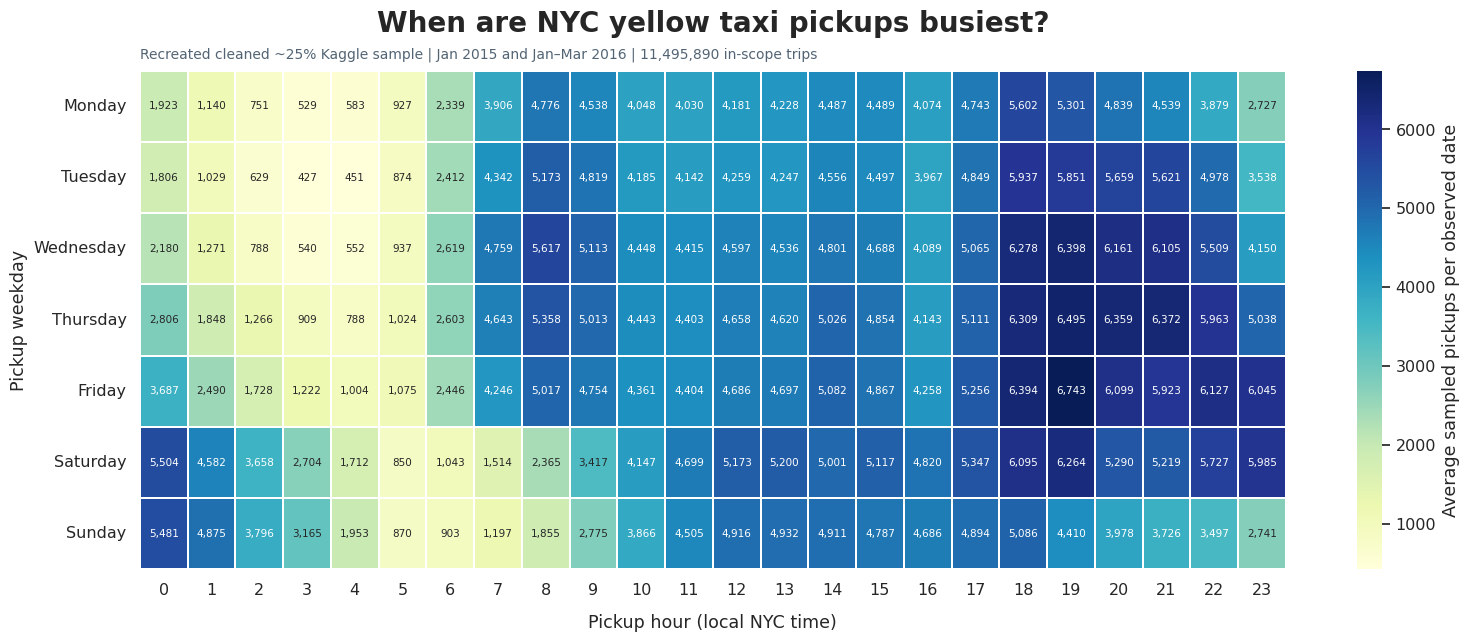

**Insight:** The highest average is 6,743 pickups on Friday at 19:00. The lowest is 427 on Tuesday at 03:00.

**EDA decision:** Retain pickup hour, weekday and a weekend flag as pickup-time candidates. Compare fare and card-tip summaries for the same cells; busy periods need not be expensive.

In [ ]:
hour_counts = aggregate_hours(analysis)
count_matrix = (hour_counts.pivot(index='weekday_code', columns='pickup_hour', values='trip_count')
                .reindex(index=range(7), columns=range(24)).fillna(0).astype('int64'))
heatmap_values = count_matrix.div(days_per_weekday.replace(0, np.nan), axis=0)
heatmap_values.index = WEEKDAYS
heatmap_values.columns.name = 'Pickup hour'
hour_counts.to_csv(OUTPUT_DIR / 'tables' / '03_weekday_hour_raw_counts.csv', index=False)
heatmap_values.to_csv(OUTPUT_DIR / 'tables' / '04_weekday_hour_average_pickups.csv', index_label='weekday')

fig, ax = plt.subplots(figsize=(16, 6.6))
sns.heatmap(heatmap_values, cmap='YlGnBu', annot=True, fmt=',.0f',
            annot_kws={'fontsize': 7.5}, linewidths=0.25, linecolor='white',
            cbar_kws={'label': 'Average sampled pickups per observed date'}, ax=ax)
ax.set_title('When are NYC yellow taxi pickups busiest?', fontsize=20, pad=28)
ax.text(0, 1.025, SCOPE_TEXT, transform=ax.transAxes, fontsize=10, color='#526474')
ax.set_xlabel('Pickup hour (local NYC time)', labelpad=12)
ax.set_ylabel('Pickup weekday')
ax.tick_params(axis='y', rotation=0)
fig.tight_layout()
save_figure(fig, 'eda_1.png')
plt.show()

cells_series = heatmap_values.stack()
peak_weekday, peak_hour = cells_series.idxmax()
low_weekday, low_hour = cells_series.idxmin()
peak_average = float(cells_series.max())
low_average = float(cells_series.min())
record_insight(
    '1. Heatmap', 'When are pickups busiest?',
    f'The highest average is {peak_average:,.0f} pickups on {peak_weekday} at {peak_hour:02d}:00. '
    f'The lowest is {low_average:,.0f} on {low_weekday} at {low_hour:02d}:00.',
    'Retain pickup hour, weekday and a weekend flag as pickup-time candidates. Compare fare and card-tip summaries for the same cells; busy periods need not be expensive.'
)

## 5. Visualization 2: taxi-zone choropleth
**Question:** Which NYC taxi zones have the most recorded pickups?

**Measure:** Raw counts per mapped taxi zone, with a numeric colour legend. Counts are not adjusted for area or population.

**How locations are handled:** Valid existing zone IDs are retained. Other rows are matched from pickup longitude/latitude to official zone polygons. Both geometries use the same coordinate system. Points exactly on a shared boundary use the lowest matching zone ID, a deterministic rule recorded in the audit. Rows outside every taxi zone remain unmatched rather than being forced to the nearest zone. Chunking changes memory use, not the number of rows analyzed.

**Connection to fares:** A busy zone is not automatically an expensive zone. Section 6B compares fare summaries and high-fare shares using these same mapped zones. Keep an unmapped category for the later model rather than treating those rows as a real taxi zone.

### Your Tableau visual 2: original reference
The supplied Tableau image is included below. The following Python cell recomputes this figure from the cleaned trip file; these reference images are not Python results.

![Original Tableau visual 2](attachment:tableau_2.png)

In [ ]:
if not ZONE_ARCHIVE.exists():
    print('Downloading official TLC taxi-zone boundaries...')
    with urlopen(TAXI_ZONES_URL, timeout=30) as response:
        boundary_bytes = response.read()
    with zipfile.ZipFile(__import__('io').BytesIO(boundary_bytes)) as archive:
        if not any(name.lower().endswith('.shp') for name in archive.namelist()):
            raise ValueError('The downloaded archive does not contain a shapefile.')
    ZONE_ARCHIVE.write_bytes(boundary_bytes)

with zipfile.ZipFile(ZONE_ARCHIVE) as archive:
    shapefiles = [name for name in archive.namelist() if name.lower().endswith('.shp')]
if len(shapefiles) != 1:
    raise ValueError('Expected exactly one taxi-zone shapefile in the official archive.')
# The official archive may contain a nested directory; use its actual member path.
zones = gpd.read_file(f'zip://{ZONE_ARCHIVE.resolve()}!{shapefiles[0]}')
if zones.crs is None:
    raise ValueError('Zone boundaries have no coordinate system. Use the official archive including its .prj file.')
if not {'LocationID', 'zone', 'borough'}.issubset(zones.columns):
    raise ValueError(f'Unexpected taxi-zone schema: {zones.columns.tolist()}')
zones['LocationID'] = pd.to_numeric(zones['LocationID']).astype('int32')
if zones['LocationID'].duplicated().any():
    zones = zones[['LocationID', 'zone', 'borough', 'geometry']].dissolve(by='LocationID', as_index=False)
zones_wgs84 = zones[['LocationID', 'geometry']].to_crs('EPSG:4326')
valid_zone_ids = set(zones['LocationID'])

preexisting_matches = 0
if 'pickup_zone_id' in df:
    provided = df['pickup_zone_id']
    valid_id = provided.mod(1).eq(0) & provided.isin(valid_zone_ids)
    analysis.loc[valid_id, 'pickup_zone_id'] = provided.loc[valid_id].astype('int32').to_numpy()
    preexisting_matches = int(valid_id.sum())

spatial_matches = 0
multi_match_points = 0
invalid_coordinate_rows = 0
if {'pickup_longitude', 'pickup_latitude'}.issubset(df.columns):
    longitude = df['pickup_longitude'].to_numpy(dtype='float64')
    latitude = df['pickup_latitude'].to_numpy(dtype='float64')
    valid_coordinates = (np.isfinite(longitude) & np.isfinite(latitude)
                         & (longitude >= -180) & (longitude <= 180)
                         & (latitude >= -90) & (latitude <= 90)
                         & ~((longitude == 0) & (latitude == 0)))
    invalid_coordinate_rows = int((~valid_coordinates).sum())
    to_match = np.flatnonzero(analysis['pickup_zone_id'].lt(0).to_numpy() & valid_coordinates)
    for number, start in enumerate(range(0, len(to_match), MAP_CHUNK_SIZE), start=1):
        positions = to_match[start:start + MAP_CHUNK_SIZE]
        points = gpd.GeoDataFrame(
            {'row_position': positions},
            geometry=gpd.points_from_xy(longitude[positions], latitude[positions]),
            crs='EPSG:4326',
        )
        joined = gpd.sjoin(points, zones_wgs84, how='left', predicate='intersects')
        matched = joined.dropna(subset=['LocationID'])
        multi_match_points += int(matched.groupby('row_position').size().gt(1).sum())
        best_zone = matched.groupby('row_position')['LocationID'].min().astype('int32')
        analysis.loc[best_zone.index, 'pickup_zone_id'] = best_zone.to_numpy()
        spatial_matches += len(best_zone)
        if number == 1 or number % 10 == 0 or start + MAP_CHUNK_SIZE >= len(to_match):
            print(f'GPS matching: processed {min(start + MAP_CHUNK_SIZE, len(to_match)):,}/{len(to_match):,} rows')
        del points, joined, matched
    del longitude, latitude, valid_coordinates, to_match

MAPPED_ROWS = int(analysis['pickup_zone_id'].gt(0).sum())
UNMAPPED_ROWS = N_SCOPE - MAPPED_ROWS
map_audit = pd.DataFrame({
    'Check': ['Rows in project scope', 'Valid existing zone IDs', 'Matched using GPS',
              'Unmatched pickups', 'Missing/invalid coordinates (may still have a valid zone ID)',
              'GPS points intersecting multiple zone polygons'],
    'Rows': [N_SCOPE, preexisting_matches, spatial_matches, UNMAPPED_ROWS,
             invalid_coordinate_rows, multi_match_points],
})
display(map_audit)
map_audit.to_csv(OUTPUT_DIR / 'tables' / '05_location_mapping_audit.csv', index=False)
if MAPPED_ROWS == 0:
    raise ValueError('No pickups matched the TLC taxi zones. Check coordinate order, CRS and input zone IDs.')

zone_counts = aggregate_zones(analysis)
map_data = zones.merge(zone_counts, left_on='LocationID', right_on='pickup_zone_id', how='left', validate='one_to_one')
map_data['trip_count'] = map_data['trip_count'].fillna(0).astype('int64')
zone_table = (map_data[['LocationID', 'zone', 'borough', 'trip_count']]
              .sort_values('trip_count', ascending=False).reset_index(drop=True))
assert int(zone_table['trip_count'].sum()) == MAPPED_ROWS
zone_table.to_csv(OUTPUT_DIR / 'tables' / '06_pickups_by_taxi_zone.csv', index=False)
display(zone_table.head(10))

# Release the timestamp and coordinate columns; retain all rows of the five-column analysis frame.
del df, pickup
gc.collect()

GPS matching: processed 200,000/11,495,890 rows
GPS matching: processed 2,000,000/11,495,890 rows
GPS matching: processed 4,000,000/11,495,890 rows
GPS matching: processed 6,000,000/11,495,890 rows
GPS matching: processed 8,000,000/11,495,890 rows
GPS matching: processed 10,000,000/11,495,890 rows
GPS matching: processed 11,495,890/11,495,890 rows


,Check,Rows
0,Rows in project scope,11495890
1,Valid existing zone IDs,0
2,Matched using GPS,11491488
3,Unmatched pickups,4402
4,Missing/invalid coordinates (may still have a ...,0
5,GPS points intersecting multiple zone polygons,0


,LocationID,zone,borough,trip_count
0,237,Upper East Side South,Manhattan,431383
1,161,Midtown Center,Manhattan,426676
2,236,Upper East Side North,Manhattan,405191
3,234,Union Sq,Manhattan,395096
4,162,Midtown East,Manhattan,391309
5,79,East Village,Manhattan,388961
6,230,Times Sq/Theatre District,Manhattan,387945
7,186,Penn Station/Madison Sq West,Manhattan,382213
8,170,Murray Hill,Manhattan,376979
9,48,Clinton East,Manhattan,362833


56

Saved: /content/member2_eda_outputs/figures/eda_2.png


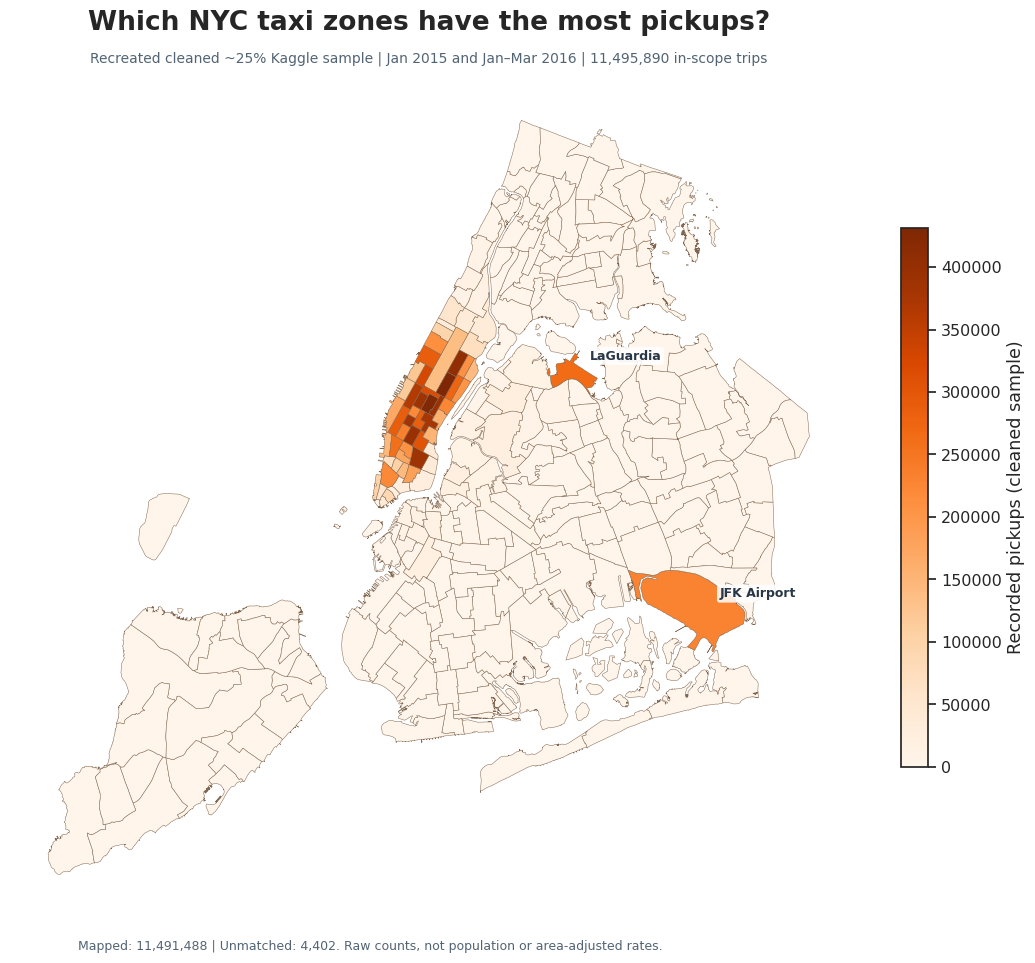

,LocationID,zone,borough,trip_count,share_of_mapped_pickups_pct
17,138,LaGuardia Airport,Queens,265849,2.313443
20,132,JFK Airport,Queens,229943,2.000985


**Insight:** The largest count is in Upper East Side South: 431,383 pickups. Manhattan contains 92.8% of mapped pickups. 4,402 rows are unmapped.

**EDA decision:** Evaluate pickup zone and an airport flag as pickup-time features. Compare their fare summaries directly before judging predictive strength; preserve valid airport trips.

In [ ]:
fig, ax = plt.subplots(figsize=(11, 9.5))
map_data.plot(column='trip_count', cmap='Oranges', edgecolor='#80664f', linewidth=0.35,
              legend=True, legend_kwds={'label': 'Recorded pickups (cleaned sample)', 'shrink': 0.65}, ax=ax)
ax.set_title('Which NYC taxi zones have the most pickups?', fontsize=19, pad=38)
ax.text(0.5, 1.025, SCOPE_TEXT, ha='center', transform=ax.transAxes, fontsize=10, color='#526474')
for zone_id, label in [(132, 'JFK Airport'), (138, 'LaGuardia')]:
    geometry = map_data.loc[map_data['LocationID'].eq(zone_id), 'geometry']
    if not geometry.empty:
        point = geometry.iloc[0].representative_point()
        ax.annotate(label, xy=(point.x, point.y), xytext=(12, 10), textcoords='offset points',
                    fontsize=9, fontweight='bold', color='#273747',
                    bbox={'boxstyle': 'round,pad=0.2', 'fc': 'white', 'ec': 'none', 'alpha': 0.85})
ax.set_axis_off()
fig.text(0.09, 0.02, f'Mapped: {MAPPED_ROWS:,} | Unmatched: {UNMAPPED_ROWS:,}. Raw counts, not population or area-adjusted rates.',
         fontsize=9, color='#526474')
fig.tight_layout(rect=[0, 0.04, 1, 1])
save_figure(fig, 'eda_2.png')
plt.show()

top_zone = zone_table.iloc[0]
borough_counts = zone_table.groupby('borough')['trip_count'].sum().sort_values(ascending=False)
manhattan_share = 100 * float(borough_counts.get('Manhattan', 0)) / MAPPED_ROWS
airport_rows = zone_table.loc[zone_table['LocationID'].isin([132, 138])].copy()
airport_rows['share_of_mapped_pickups_pct'] = airport_rows['trip_count'] / MAPPED_ROWS * 100
display(airport_rows)
record_insight(
    '2. Choropleth', 'Which taxi zones have the most recorded pickups?',
    f'The largest count is in {top_zone["zone"]}: {int(top_zone["trip_count"]):,} pickups. '
    f'Manhattan contains {manhattan_share:.1f}% of mapped pickups. {UNMAPPED_ROWS:,} rows are unmapped.',
    'Evaluate pickup zone and an airport flag as pickup-time features. Compare their fare summaries directly before judging predictive strength; preserve valid airport trips.'
)

## 6. Visualization 3: passenger groups and trip length
**Question:** Do larger passenger groups take longer trips?

**Measure:** The percentage of valid trips in each distance bin **within each passenger group**. Each group totals 100%, so a larger number of one-passenger trips cannot dominate the comparison.

**Purpose even when groups look similar:** This tests the assumption that more passengers implies a longer trip. A similar distribution is a useful finding, but it does not establish statistical equivalence or prove that passenger count has no value for predicting fares. Keep passenger count as a candidate and evaluate it with time and location.

**Connection to fares:** Trip length is a possible explanation for fare differences. Section 6B checks fares within each passenger group directly. Distance is unavailable at pickup, so this distance-based EDA must not put distance into the pickup-time classifier.

### Your Tableau visual 3: original reference
The supplied Tableau image is included below. The following Python cell recomputes this figure from the cleaned trip file; these reference images are not Python results.

![Original Tableau visual 3](attachment:tableau_3.png)

,Short (<2 miles),Medium (2–<5 miles),Long (5+ miles)
1 passenger,58.07,28.50,13.42
2 passengers,55.79,29.25,14.96
3–6 passengers,57.00,28.85,14.15


,Short (<2 miles),Medium (2–<5 miles),Long (5+ miles),valid_trips
1 passenger,4728375,2320672,1093023,8142070
2 passengers,915210,479817,245477,1640504
3–6 passengers,976596,494281,242439,1713316


Rows used for grouped bars: 11,495,890; excluded from this chart: 0.
Saved: /content/member2_eda_outputs/figures/eda_3.png


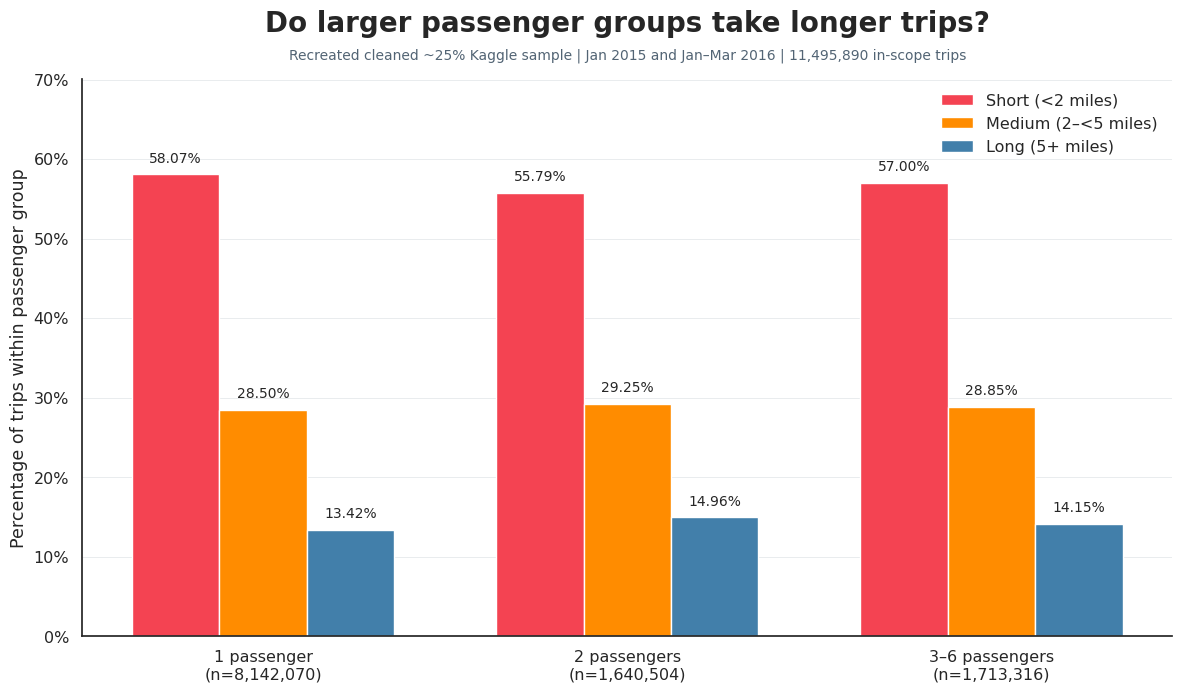

**Insight:** Long-trip shares are 1 passenger: 13.42%, 2 passengers: 14.96%, 3–6 passengers: 14.15%. There is no steady rise in long-trip share with group size.

**EDA decision:** Evaluate passenger count alongside pickup time and location. This chart alone does not establish its ML importance.

In [ ]:
group_distance_counts = aggregate_group_distance(analysis)
valid_group_count = int(group_distance_counts['trip_count'].sum())
group_excluded = N_SCOPE - valid_group_count
if valid_group_count == 0:
    raise ValueError('No positive-distance trips with integer passenger counts 1–6 are available.')

group_counts = (group_distance_counts.pivot(index='passenger_group_code', columns='trip_length_code', values='trip_count')
                .reindex(index=range(3), columns=range(3)).fillna(0).astype('int64'))
group_totals = group_counts.sum(axis=1)
group_percentages = group_counts.div(group_totals.replace(0, np.nan), axis=0) * 100
populated_groups = group_totals.gt(0)
assert np.allclose(group_percentages.loc[populated_groups].sum(axis=1), 100.0)

percentage_table = group_percentages.copy()
percentage_table.index = PASSENGER_LABELS
percentage_table.columns = DISTANCE_LABELS
count_table = group_counts.copy()
count_table.index = PASSENGER_LABELS
count_table.columns = DISTANCE_LABELS
count_table['valid_trips'] = group_totals.to_numpy()
percentage_table.to_csv(OUTPUT_DIR / 'tables' / '07_group_trip_length_percentages.csv', index_label='passenger_group')
count_table.to_csv(OUTPUT_DIR / 'tables' / '08_group_trip_length_counts.csv', index_label='passenger_group')
display(percentage_table.round(2))
display(count_table)
print(f'Rows used for grouped bars: {valid_group_count:,}; excluded from this chart: {group_excluded:,}.')

fig, ax = plt.subplots(figsize=(12, 7.1))
x = np.arange(3)
width = 0.24
colors = ['#f44352', '#ff8c00', '#427faa']
for length_code, (label, color) in enumerate(zip(DISTANCE_LABELS, colors)):
    bars = ax.bar(x + (length_code - 1) * width, group_percentages[length_code], width, label=label, color=color)
    for bar in bars:
        value = bar.get_height()
        if np.isfinite(value):
            ax.text(bar.get_x() + bar.get_width()/2, value + 1.1, f'{value:.2f}%',
                    ha='center', va='bottom', fontsize=10)
ax.set_xticks(x, [f'{label}\n(n={int(n):,})' for label, n in zip(PASSENGER_LABELS, group_totals)])
ax.set_ylabel('Percentage of trips within passenger group')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(100))
ax.set_ylim(0, min(110, max(70, float(group_percentages.max().max()) + 12)))
ax.set_title('Do larger passenger groups take longer trips?', fontsize=20, pad=34)
ax.text(0.5, 1.035, SCOPE_TEXT, ha='center', transform=ax.transAxes, fontsize=10, color='#526474')
ax.legend(frameon=False, loc='upper right')
ax.grid(axis='y', color='#e5e9eb', linewidth=0.6)
ax.set_axisbelow(True)
sns.despine(ax=ax)
fig.tight_layout()
save_figure(fig, 'eda_3.png')
plt.show()

long_shares = group_percentages[2]
complete_groups = bool(populated_groups.all())
if complete_groups:
    steady_increase = bool(np.all(np.diff(long_shares.to_numpy()) > 0))
    pattern = 'The long-trip share increases across these three groups.' if steady_increase else 'There is no steady rise in long-trip share with group size.'
else:
    pattern = 'One or more groups are empty, so this file does not support the complete three-group comparison.'
long_text = ', '.join(f'{label}: {value:.2f}%' for label, value in zip(PASSENGER_LABELS, long_shares) if np.isfinite(value))
record_insight(
    '3. Grouped bars', 'Do larger passenger groups take longer trips?',
    f'Long-trip shares are {long_text}. {pattern}',
    'Evaluate passenger count alongside pickup time and location. This chart alone does not establish its ML importance.'
)

## 6B. Supporting EDA: connect the three figures to fares and tips

The three figures above remain my main visualizations. These supporting **tables** answer the group's fare question using their same time, zone and passenger categories:

1. Do the busiest weekday/hour cells also have the highest median fares?
2. How do fare and high-fare shares differ across pickup zones?
3. Do passenger-group fare patterns support the trip-length finding?

**Target definition:** High-fare means `fare_amount > cutoff`. If the team has an agreed training-derived cutoff, enter it in the configuration. Otherwise, use the 80th percentile of valid fares from **January 2015 and January–February 2016 only**. March 2016 is reserved for the planned test period and cannot determine the cutoff. Discrete fares and ties mean the observed positive share can differ from exactly 20%. This is target exploration, not a fitted model.

**Tips:** Tip percentage here is `100 × recorded tip / base fare`, on valid credit-card trips only. It is not tip as a percentage of total charged. Outcomes such as fare, tips and distance are used to understand patterns; they are not pickup-time input features.

Read group sizes as well as percentages. Groups with fewer than `MIN_COMPARISON_ROWS` valid fares are retained in exported tables but excluded from the automatic highest/lowest comparisons. Descriptive differences do not show causation or statistical significance.

In [ ]:
SUPPORTING_EDA_TEXT = []
supporting_status = 'NOT RUN: fare_amount absent'
target_summary = pd.DataFrame()
time_fare_summary = pd.DataFrame()
zone_fare_summary = pd.DataFrame()
passenger_fare_summary = pd.DataFrame()

if fare_context is not None:
    valid_fare = fare_context['valid_fare']
    reference_mask = valid_fare & fare_context['pickup_month_code'].isin(REFERENCE_MONTH_CODES)
    if HIGH_FARE_CUTOFF is not None:
        fare_cutoff = float(HIGH_FARE_CUTOFF)
        if not np.isfinite(fare_cutoff) or fare_cutoff <= 0:
            raise ValueError('HIGH_FARE_CUTOFF must be a positive finite dollar amount.')
        threshold_origin = 'Team-supplied training-derived cutoff; verify its provenance with Member 3.'
    elif reference_mask.any():
        fare_cutoff = float(fare_context.loc[reference_mask, 'fare_amount'].quantile(HIGH_FARE_QUANTILE))
        threshold_origin = '80th percentile using Jan 2015 and Jan–Feb 2016; March 2016 excluded.'
    else:
        threshold_origin = 'Unavailable: no positive finite fares in the designated reference months.'
        print(threshold_origin)

    fare_context['fare_amount'] = fare_context['fare_amount'].where(valid_fare)
    fare_context['high_fare'] = np.nan
    if fare_cutoff is not None:
        fare_context.loc[valid_fare, 'high_fare'] = (
            fare_context.loc[valid_fare, 'fare_amount'].gt(fare_cutoff).astype('float64'))
    card_tip_valid = (fare_context['payment_type'].eq(1) & valid_fare
                      & np.isfinite(fare_context['tip_amount']) & fare_context['tip_amount'].ge(0))
    fare_context['card_tip_pct'] = (
        100 * fare_context['tip_amount'] / fare_context['fare_amount']).where(card_tip_valid)
    fare_context['pickup_zone_id'] = analysis['pickup_zone_id']
    p = analysis['passenger_count']
    valid_passenger = p.ge(1) & p.le(6) & p.mod(1).eq(0)
    fare_context['passenger_group_code'] = (
        p.gt(1).astype('int8') + p.gt(2).astype('int8')).where(valid_passenger)

    target_rows = []
    for period_name, period_mask in (
        ('Reference months (cutoff estimation)', reference_mask),
        ('March 2016 (planned test)', valid_fare & fare_context['pickup_month_code'].eq(201603)),
        ('All in-scope valid fares (descriptive)', valid_fare),
    ):
        values = fare_context.loc[period_mask]
        share = values['high_fare'].mean() * 100 if len(values) else np.nan
        target_rows.append({'period': period_name, 'valid_fare_trips': len(values),
                            'mean_fare_usd': values['fare_amount'].mean(),
                            'median_fare_usd': values['fare_amount'].median(),
                            'high_fare_cutoff_usd': fare_cutoff, 'high_fare_share_pct': share})
    target_summary = pd.DataFrame(target_rows)
    display(Markdown('### Fare distribution and proposed target'))
    display(target_summary.round(3))
    print('Cutoff source:', threshold_origin)
    print(f'Invalid or missing fares excluded from outcome summaries: {int((~valid_fare).sum()):,}.')
    print(f'Valid recorded-card-tip rows: {int(card_tip_valid.sum()):,}; cash tips are not inferred from zero.')
    target_summary.to_csv(OUTPUT_DIR / 'tables' / '14_fare_target_summary.csv', index=False)

    def summarize_outcomes(frame, keys):
        result = frame.groupby(keys, dropna=False).agg(
            recorded_pickups=('fare_amount', 'size'),
            valid_fare_trips=('fare_amount', 'count'),
            mean_fare_usd=('fare_amount', 'mean'),
            median_fare_usd=('fare_amount', 'median'),
            high_fare_share_pct=('high_fare', 'mean'),
            valid_card_tip_trips=('card_tip_pct', 'count'),
            median_card_tip_pct=('card_tip_pct', 'median'),
        ).reset_index()
        result['high_fare_share_pct'] *= 100
        result['comparison_supported'] = result['valid_fare_trips'].ge(MIN_COMPARISON_ROWS)
        return result

    time_fare_summary = summarize_outcomes(fare_context, ['weekday_code', 'pickup_hour'])
    time_fare_summary['weekday'] = time_fare_summary['weekday_code'].map(dict(enumerate(WEEKDAYS)))
    time_fare_summary['average_sampled_pickups_per_date'] = (
        time_fare_summary['recorded_pickups'] /
        time_fare_summary['weekday_code'].map(days_per_weekday))
    time_fare_summary.to_csv(OUTPUT_DIR / 'tables' / '15_time_fare_tip_summary.csv', index=False)
    display(Markdown('### Figure 1 connection: activity and price are different measures'))
    display(time_fare_summary.sort_values('average_sampled_pickups_per_date', ascending=False).head(10).round(3))
    supported_time = time_fare_summary.loc[time_fare_summary['comparison_supported']]
    if not supported_time.empty:
        busy = supported_time.loc[supported_time['average_sampled_pickups_per_date'].idxmax()]
        expensive = supported_time.loc[supported_time['median_fare_usd'].idxmax()]
        sentence = (f'Among cells with at least {MIN_COMPARISON_ROWS:,} valid fares, the busiest is '
                    f'{busy["weekday"]} {int(busy["pickup_hour"]):02d}:00 '
                    f'(median fare ${busy["median_fare_usd"]:.2f}); the highest median fare is '
                    f'${expensive["median_fare_usd"]:.2f} at '
                    f'{expensive["weekday"]} {int(expensive["pickup_hour"]):02d}:00. '
                    'If there are tied maxima, this reports the first cell in the table.')
        SUPPORTING_EDA_TEXT.append(sentence)
        display(Markdown('**Measured finding:** ' + sentence))

    zone_fare_summary = summarize_outcomes(fare_context, ['pickup_zone_id'])
    zone_fare_summary = zone_fare_summary.merge(
        zone_table[['LocationID', 'zone', 'borough']], left_on='pickup_zone_id',
        right_on='LocationID', how='left', validate='one_to_one')
    zone_fare_summary['zone'] = zone_fare_summary['zone'].fillna('Unmapped pickup')
    zone_fare_summary['borough'] = zone_fare_summary['borough'].fillna('Unknown')
    zone_fare_summary['airport_pickup'] = zone_fare_summary['pickup_zone_id'].isin([132, 138])
    zone_fare_summary['share_of_all_scope_pickups_pct'] = zone_fare_summary['recorded_pickups'] / N_SCOPE * 100
    zone_fare_summary.to_csv(OUTPUT_DIR / 'tables' / '16_zone_fare_summary.csv', index=False)
    display(Markdown('### Figure 2 connection: compare fares in the busiest zones and airport zones'))
    show_zones = pd.concat([
        zone_fare_summary.sort_values('recorded_pickups', ascending=False).head(8),
        zone_fare_summary.loc[zone_fare_summary['airport_pickup']],
    ]).drop_duplicates(subset='pickup_zone_id')
    display(show_zones[['zone', 'recorded_pickups', 'median_fare_usd', 'high_fare_share_pct',
                       'valid_fare_trips', 'comparison_supported']].round(3))
    supported_zones = zone_fare_summary.loc[
        zone_fare_summary['comparison_supported'] & zone_fare_summary['pickup_zone_id'].gt(0)]
    if not supported_zones.empty:
        highest = supported_zones.loc[supported_zones['median_fare_usd'].idxmax()]
        sentence = (f'Among mapped zones with at least {MIN_COMPARISON_ROWS:,} valid fares, '
                    f'{highest["zone"]} has the highest median fare (${highest["median_fare_usd"]:.2f}); '
                    'ties report the first zone. This is a descriptive comparison, not model importance.')
        SUPPORTING_EDA_TEXT.append(sentence)
        display(Markdown('**Measured finding:** ' + sentence))

    passenger_fare_summary = summarize_outcomes(
        fare_context.loc[valid_passenger], ['passenger_group_code'])
    passenger_fare_summary['passenger_group'] = passenger_fare_summary['passenger_group_code'].map(
        dict(enumerate(PASSENGER_LABELS)))
    passenger_fare_summary['long_trip_share_pct_from_figure_3'] = (
        passenger_fare_summary['passenger_group_code'].map(group_percentages[2]))
    passenger_fare_summary.to_csv(OUTPUT_DIR / 'tables' / '17_passenger_group_fare_summary.csv', index=False)
    display(Markdown('### Figure 3 connection: check fares directly instead of assuming a relationship'))
    display(passenger_fare_summary[['passenger_group', 'valid_fare_trips', 'median_fare_usd',
                                   'high_fare_share_pct', 'long_trip_share_pct_from_figure_3']].round(3))
    print('Fare summaries need a valid fare and passenger group; the trip-length percentage also needs valid distance.')
    print('Compare the recorded group sizes before drawing conclusions; statistical tests were not performed.')
    supporting_status = 'EXECUTED: fare and group summaries; recorded card tips where available'
else:
    display(Markdown('**Supporting fare EDA was not run:** this input lacks `fare_amount`. '
                     'Use the full cleaned file with fare, tip and payment fields to complete the problem-statement analysis.'))

### Fare distribution and proposed target

,period,valid_fare_trips,mean_fare_usd,median_fare_usd,high_fare_cutoff_usd,high_fare_share_pct
0,Reference months (cutoff estimation),8520428,12.158,9.0,15.5,19.624
1,March 2016 (planned test),2975462,12.661,9.5,15.5,21.500
2,All in-scope valid fares (descriptive),11495890,12.289,9.0,15.5,20.109


Cutoff source: 80th percentile using Jan 2015 and Jan–Feb 2016; March 2016 excluded.
Invalid or missing fares excluded from outcome summaries: 0.
Valid recorded-card-tip rows: 7,548,843; cash tips are not inferred from zero.


### Figure 1 connection: activity and price are different measures

,weekday_code,pickup_hour,recorded_pickups,valid_fare_trips,mean_fare_usd,median_fare_usd,high_fare_share_pct,valid_card_tip_trips,median_card_tip_pct,comparison_supported,weekday,average_sampled_pickups_per_date
115,4,19,121370,121370,11.491,9.0,16.898,81685,23.125,True,Friday,6742.778
91,3,19,116902,116902,11.607,9.0,17.338,81637,23.130,True,Thursday,6494.556
67,2,19,108771,108771,11.344,9.0,16.326,76792,23.333,True,Wednesday,6398.294
114,4,18,115085,115085,11.735,9.0,17.386,75890,23.182,True,Friday,6393.611
93,3,21,114698,114698,12.582,9.5,22.252,82545,22.261,True,Thursday,6372.111
92,3,20,114467,114467,12.043,9.0,19.744,82096,22.273,True,Thursday,6359.278
90,3,18,113559,113559,11.819,9.0,17.971,76762,23.273,True,Thursday,6308.833
66,2,18,106724,106724,11.639,9.0,17.300,73517,23.333,True,Wednesday,6277.882
139,5,19,112758,112758,11.340,9.0,16.918,71107,21.391,True,Saturday,6264.333
68,2,20,104745,104745,11.829,9.0,18.533,76449,22.381,True,Wednesday,6161.471


...

,zone,recorded_pickups,median_fare_usd,high_fare_share_pct,valid_fare_trips,comparison_supported
233,Upper East Side South,431383,7.5,9.800,431383,True
158,Midtown Center,426676,9.0,14.410,426676,True
232,Upper East Side North,405191,8.0,12.307,405191,True
230,Union Sq,395096,8.5,13.815,395096,True
159,Midtown East,391309,9.0,14.734,391309,True
78,East Village,388961,9.5,18.125,388961,True
226,Times Sq/Theatre District,387945,9.0,18.531,387945,True
183,Penn Station/Madison Sq West,382213,9.0,15.037,382213,True
129,JFK Airport,229943,52.0,96.388,229943,True
135,LaGuardia Airport,265849,30.5,93.772,265849,True


**Measured finding:** Among mapped zones with at least 100 valid fares, Baisley Park has the highest median fare ($52.00); ties report the first zone. This is a descriptive comparison, not model importance.

### Figure 3 connection: check fares directly instead of assuming a relationship

,passenger_group,valid_fare_trips,median_fare_usd,high_fare_share_pct,long_trip_share_pct_from_figure_3
0,1 passenger,8142070,9.0,19.690,13.424
1,2 passengers,1640504,9.5,21.640,14.964
2,3–6 passengers,1713316,9.0,20.637,14.150


Fare summaries need a valid fare and passenger group; the trip-length percentage also needs valid distance.
Compare the recorded group sizes before drawing conclusions; statistical tests were not performed.


### Decisions from this EDA and handoff to Member 3
The figures identify patterns; the supporting tables check how those patterns relate to outcomes. A feature's predictive value still needs validation in the later model.

In [ ]:
feature_decisions = pd.DataFrame([
    {'candidate': 'Pickup hour, weekday, weekend', 'EDA evidence': 'Figure 1 plus weekday/hour fare and card-tip table',
     'decision': 'Evaluate together; do not equate pickup volume with high fares.', 'known_at_pickup': True},
    {'candidate': 'Pickup zone and airport flag', 'EDA evidence': 'Figure 2 plus same-zone fare table',
     'decision': 'Evaluate location effects; keep valid airport trips and an unknown-location category.', 'known_at_pickup': True},
    {'candidate': 'Passenger count', 'EDA evidence': 'Figure 3 plus passenger-group fare table',
     'decision': 'Keep as a candidate; similar trip-length shares do not prove no fare-prediction value.', 'known_at_pickup': True},
    {'candidate': 'Trip distance, duration and dropoff', 'EDA evidence': 'Distance used to explain trip characteristics',
     'decision': 'EDA only; unavailable at pickup, so exclude from the pickup-time classifier.', 'known_at_pickup': False},
    {'candidate': 'Fare, recorded tip, total amount and payment outcome', 'EDA evidence': 'Outcome summaries and target definition',
     'decision': 'Fare defines the target; realized outcomes are not pickup-time input features.', 'known_at_pickup': False},
])
display(feature_decisions)
feature_decisions.to_csv(OUTPUT_DIR / 'tables' / '18_feature_decisions.csv', index=False)
print('No model was trained. Member 3 can use these summaries to justify candidate features and evaluation.')

,candidate,EDA evidence,decision,known_at_pickup
0,"Pickup hour, weekday, weekend",Figure 1 plus weekday/hour fare and card-tip t...,Evaluate together; do not equate pickup volume...,True
1,Pickup zone and airport flag,Figure 2 plus same-zone fare table,Evaluate location effects; keep valid airport ...,True
2,Passenger count,Figure 3 plus passenger-group fare table,Keep as a candidate; similar trip-length share...,True
3,"Trip distance, duration and dropoff",Distance used to explain trip characteristics,"EDA only; unavailable at pickup, so exclude fr...",False
4,"Fare, recorded tip, total amount and payment o...",Outcome summaries and target definition,Fare defines the target; realized outcomes are...,False


No model was trained. Member 3 can use these summaries to justify candidate features and evaluation.


### Check against your presentation
Your supplied chart showed **6,739** for Friday 19:00 and **422** for Tuesday 03:00. Its long-trip shares were **13.41%**, **14.95%** and **14.18%**.

The table below compares those displayed values with this run; it does not force a match. If values differ, check the input file, the cleaning version and sampling seed, the four-month filter, Tableau filters, and whether the heatmap uses a per-observed-date average. A 50,000-row preview will not reproduce the full-sample counts. The map also depends on which zone-matching method Tableau used.

In [ ]:
slide_comparison = pd.DataFrame({
    'Metric': ['Friday 19:00 average', 'Tuesday 03:00 average',
               'Long-trip %: 1 passenger', 'Long-trip %: 2 passengers', 'Long-trip %: 3–6 passengers'],
    'Displayed in supplied slides': [6739, 422, 13.41, 14.95, 14.18],
    'Recomputed from this file': [heatmap_values.loc['Friday', 19], heatmap_values.loc['Tuesday', 3],
                                  group_percentages.loc[0, 2], group_percentages.loc[1, 2], group_percentages.loc[2, 2]],
})
slide_comparison['Difference'] = (slide_comparison['Recomputed from this file']
                                - slide_comparison['Displayed in supplied slides'])
display(slide_comparison.round(2))
slide_comparison.to_csv(OUTPUT_DIR / 'tables' / '09_slide_value_comparison.csv', index=False)

,Metric,Displayed in supplied slides,Recomputed from this file,Difference
0,Friday 19:00 average,6739.00,6742.78,3.78
1,Tuesday 03:00 average,422.00,426.88,4.88
2,Long-trip %: 1 passenger,13.41,13.42,0.01
3,Long-trip %: 2 passengers,14.95,14.96,0.01
4,Long-trip %: 3–6 passengers,14.18,14.15,-0.03


## 7. RAPIDS/cuDF: real GPU EDA and CPU comparison

**What runs on the GPU:** Counting weekday/hour combinations, filtering and binning passenger/distance rows, and counting already-mapped pickup zones. These operations scan many trip rows and combine them into small summary tables.

**What stays on the CPU:** Loading and scope checks in this notebook, datetime feature preparation, polygon matching with GeoPandas, interpreting the summaries, and drawing the Matplotlib charts. This experiment does not claim GPU acceleration for those steps.

**Fair comparison:** Both backends use the same complete five-column `analysis` table and the same functions. Warm-up runs are excluded. GPU work is synchronized before timing ends. The table reports the median of three repetitions, checks exact count equality, and also measures a complete aggregation pass including CPU→GPU input transfer and GPU→CPU summary transfer. The transfer-inclusive pass still excludes file loading and spatial matching, which both backends share. A speedup below 1 means the CPU was faster on that measured task.

If this section cannot access a working cuDF GPU, it raises an actionable error when `RUN_GPU=True`; it never records invented timings or a completed GPU experiment.

In [ ]:
benchmark_table = pd.DataFrame(columns=['Task', 'Rows in input', 'pandas CPU seconds',
                                       'cuDF GPU seconds', 'CPU/GPU speedup', 'Counts equal'])
benchmark_runs = []
gpu_versions = {}
transfer_seconds = None

def median_runtime(function, sync=None):
    elapsed = []
    result = None
    for _ in range(BENCHMARK_REPEATS):
        if sync:
            sync()
        start = time.perf_counter()
        result = function()
        if sync:
            sync()
        elapsed.append(time.perf_counter() - start)
    return float(np.median(elapsed)), elapsed, result

def normalize_counts(table):
    keys = [c for c in table.columns if c != 'trip_count']
    return table.sort_values(keys).reset_index(drop=True)

if RUN_GPU:
    try:
        import cudf
        import cupy as cp
        if cp.cuda.runtime.getDeviceCount() < 1:
            raise RuntimeError('CUDA reports no usable device.')
        cp.cuda.runtime.deviceSynchronize()
    except Exception as exc:
        GPU_STATUS = 'NOT EXECUTED: GPU/cuDF unavailable'
        raise RuntimeError(
            'GPU experiment not executed. In Colab choose Runtime > Change runtime type > GPU, '
            'run setup again and verify import cudf plus nvidia-smi. '
            'For a CPU preview only, set RUN_GPU=False and rerun. This does not complete the GPU requirement.'
        ) from exc

    sync_gpu = cp.cuda.runtime.deviceSynchronize
    props = cp.cuda.runtime.getDeviceProperties(0)
    device_name = props.get('name', 'NVIDIA GPU')
    if isinstance(device_name, bytes):
        device_name = device_name.decode()
    gpu_versions = {'cuDF': cudf.__version__, 'CuPy': cp.__version__, 'GPU': str(device_name),
                    'CUDA runtime version': cp.cuda.runtime.runtimeGetVersion(),
                    'CUDA driver version': cp.cuda.runtime.driverGetVersion()}
    display(pd.DataFrame({'Environment': list(gpu_versions), 'Value': list(gpu_versions.values())}))

    # Full in-scope input. No head(), sample() or reduced benchmark slice is used.
    sync_gpu()
    transfer_start = time.perf_counter()
    gpu_analysis = cudf.from_pandas(analysis)
    sync_gpu()
    transfer_seconds = time.perf_counter() - transfer_start
    print(f'Initial full-input CPU→GPU transfer: {transfer_seconds:.4f} seconds for {len(analysis):,} rows.')

    tasks = {'Weekday/hour counts': aggregate_hours,
             'Passenger/distance counts': aggregate_group_distance,
             'Mapped pickup-zone counts': aggregate_zones}
    measured_rows = []
    reference_results = {}
    for label, function in tasks.items():
        function(analysis)  # CPU warm-up
        function(gpu_analysis)  # GPU warm-up
        sync_gpu()
        cpu_s, cpu_repeats, cpu_result = median_runtime(lambda: function(analysis))
        gpu_s, gpu_repeats, gpu_result = median_runtime(lambda: function(gpu_analysis), sync=sync_gpu)
        gpu_result_host = gpu_result.to_pandas()
        pd.testing.assert_frame_equal(normalize_counts(cpu_result), normalize_counts(gpu_result_host),
                                       check_dtype=False, check_exact=True)
        reference_results[label] = cpu_result
        measured_rows.append({'Task': label, 'Rows in input': len(analysis),
                              'pandas CPU seconds': cpu_s, 'cuDF GPU seconds': gpu_s,
                              'CPU/GPU speedup': cpu_s / gpu_s, 'Counts equal': True})
        benchmark_runs.append({'task': label, 'cpu_seconds': cpu_repeats, 'gpu_seconds': gpu_repeats})
        del gpu_result, gpu_result_host

    def cpu_complete_pass():
        return {label: function(analysis) for label, function in tasks.items()}

    def gpu_transfer_inclusive_pass():
        batch = cudf.from_pandas(analysis)
        results = {label: function(batch).to_pandas() for label, function in tasks.items()}
        sync_gpu()
        return results

    cpu_complete_pass()
    gpu_transfer_inclusive_pass()
    sync_gpu()
    cpu_all_s, cpu_all_repeats, cpu_all_results = median_runtime(cpu_complete_pass)
    gpu_all_s, gpu_all_repeats, gpu_all_results = median_runtime(gpu_transfer_inclusive_pass, sync=sync_gpu)
    for label in tasks:
        pd.testing.assert_frame_equal(normalize_counts(cpu_all_results[label]), normalize_counts(gpu_all_results[label]),
                                       check_dtype=False, check_exact=True)
    measured_rows.append({'Task': 'All three aggregations, including GPU transfers', 'Rows in input': len(analysis),
                          'pandas CPU seconds': cpu_all_s, 'cuDF GPU seconds': gpu_all_s,
                          'CPU/GPU speedup': cpu_all_s / gpu_all_s, 'Counts equal': True})
    benchmark_runs.append({'task': 'transfer-inclusive pass', 'cpu_seconds': cpu_all_repeats, 'gpu_seconds': gpu_all_repeats})
    benchmark_table = pd.DataFrame(measured_rows)
    GPU_STATUS = 'EXECUTED: all aggregation count checks passed'
    display(benchmark_table.round(4))
    print(GPU_STATUS)
    print('A speedup <1 means pandas was faster. Interpret the measured result, including transfer cost.')
    del gpu_analysis
    gc.collect()
else:
    GPU_STATUS = 'NOT EXECUTED: RUN_GPU=False (CPU preview)'
    display(Markdown('**GPU work was not executed.** Three CPU charts are available, but no GPU timing or acceleration claim is valid for this run.'))

,Environment,Value
0,cuDF,26.06.00
1,CuPy,14.0.1
2,GPU,Tesla T4
3,CUDA runtime version,13000
4,CUDA driver version,13000


Initial full-input CPU→GPU transfer: 0.2991 seconds for 11,495,890 rows.


,Task,Rows in input,pandas CPU seconds,cuDF GPU seconds,CPU/GPU speedup,Counts equal
0,Weekday/hour counts,11495890,0.5693,0.0161,35.2679,True
1,Passenger/distance counts,11495890,1.7984,0.0838,21.4682,True
2,Mapped pickup-zone counts,11495890,0.5139,0.0291,17.6870,True
3,"All three aggregations, including GPU transfers",11495890,2.5115,0.1992,12.6103,True


EXECUTED: all aggregation count checks passed
A speedup <1 means pandas was faster. Interpret the measured result, including transfer cost.


In [ ]:
if not benchmark_table.empty:
    benchmark_table.to_csv(OUTPUT_DIR / 'tables' / '10_cpu_gpu_benchmark.csv', index=False)
    total = benchmark_table.iloc[-1]
    speed = float(total['CPU/GPU speedup'])
    if speed >= 1:
        result_sentence = f'The GPU aggregation pass including transfers was {speed:.2f}× faster in this run.'
    else:
        result_sentence = f'The CPU aggregation pass was {1/speed:.2f}× faster in this run, after counting GPU transfers.'
    gpu_explanation = (f'{result_sentence} Both used {len(analysis):,} in-scope rows. '
                       'All three count tables matched exactly. GPU timings exclude file reading, '
                       'datetime preparation, polygon matching and chart rendering.')
else:
    # A CPU-only rerun must not package benchmark results from an earlier GPU run.
    (OUTPUT_DIR / 'tables' / '10_cpu_gpu_benchmark.csv').unlink(missing_ok=True)
    gpu_explanation = 'GPU work has not run. No timing or speedup claim can be made.'
display(Markdown('**What I can say about RAPIDS:** ' + gpu_explanation))

**What I can say about RAPIDS:** The GPU aggregation pass including transfers was 12.61× faster in this run. Both used 11,495,890 in-scope rows. All three count tables matched exactly. GPU timings exclude file reading, datetime preparation, polygon matching and chart rendering.

## 8. Save your insights, decisions and reproducibility evidence

The decision table below is calculated from this run. The archive contains three PNGs, the exact plotted aggregates, scope and location audits, a slide-value comparison, a run manifest, and measured CPU/GPU results when executed. The original million-row trip file is not copied into this archive.

For presentation, explain the question, visible pattern and resulting decision. You do not need to explain software clicks or each line of code.

In [ ]:
decision_table = pd.DataFrame(INSIGHTS)
display(decision_table)
decision_table.to_csv(OUTPUT_DIR / 'tables' / '11_eda_decisions.csv', index=False)

input_sha = hashlib.sha256()
with input_path.open('rb') as handle:
    for block in iter(lambda: handle.read(8 * 1024 * 1024), b''):
        input_sha.update(block)

manifest = {
    'author': 'Sai Shivananda Gunda', 'role': 'Member 2: EDA visualizations and GPU experiment',
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    'input_filename': input_path.name, 'input_size_bytes': input_path.stat().st_size,
    'input_sha256': input_sha.hexdigest(), 'input_rows': INPUT_ROWS,
    'data_source': DATA_SOURCE, 'kaggle_preparation': kaggle_provenance,
    'reported_project_rows': EXPECTED_PROJECT_ROWS, 'in_scope_rows': N_SCOPE,
    'project_months': list(PROJECT_MONTHS), 'additional_sampling': False,
    'observed_dates_by_weekday': {label: int(count) for label, count in zip(WEEKDAYS, days_per_weekday)},
    'map_matched_rows': MAPPED_ROWS, 'map_unmatched_rows': UNMAPPED_ROWS,
    'map_boundary_tie_rule': 'lowest intersecting LocationID',
    'grouped_bar_rows': valid_group_count, 'grouped_bar_excluded_rows': group_excluded,
    'group_problem_statement': 'How do time of day, day of week and pickup location shape fares and tips, and can we predict a high-fare trip using only what is known at pickup?',
    'supporting_eda_status': supporting_status, 'high_fare_cutoff_usd': fare_cutoff,
    'high_fare_cutoff_origin': threshold_origin,
    'high_fare_reference_month_codes': list(REFERENCE_MONTH_CODES),
    'minimum_group_rows_for_automatic_comparisons': MIN_COMPARISON_ROWS,
    'gpu_status': GPU_STATUS, 'gpu_environment': gpu_versions,
    'gpu_input_transfer_seconds': transfer_seconds, 'benchmark_repetitions': BENCHMARK_REPEATS,
    'benchmark_runs': benchmark_runs, 'python': platform.python_version(),
    'pandas': pd.__version__, 'geopandas': gpd.__version__, 'numpy': np.__version__,
    'taxi_zone_boundary_source': TAXI_ZONES_URL,
    'taxi_zone_boundary_sha256': hashlib.sha256(ZONE_ARCHIVE.read_bytes()).hexdigest(),
}
(OUTPUT_DIR / 'run_manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')

summary_lines = ['# Member 2: EDA insights and decisions', '', f'Author: Sai Shivananda Gunda', '', SCOPE_TEXT, '']
for row in INSIGHTS:
    summary_lines.extend([f'## {row["Plot"]}', '', f'Question: {row["Question"]}', '',
                          f'Insight: {row["Measured insight"]}', '', f'Decision: {row["EDA decision"]}', ''])
summary_lines.extend(['## Supporting EDA linked to fares and tips', '', supporting_status, '',
                      *SUPPORTING_EDA_TEXT, '', '## RAPIDS/cuDF', '', GPU_STATUS, '', gpu_explanation, '',
                      'Scope: historical recorded yellow taxi trips in the supplied cleaned sample.',
                      'The grouped-bar comparison is descriptive, not a statistical equivalence test.'])
(OUTPUT_DIR / 'eda_insights.md').write_text('\n'.join(summary_lines), encoding='utf-8')

archive_path = Path('member2_eda_outputs.zip')
files_to_pack = sorted(p for p in OUTPUT_DIR.rglob('*') if p.is_file())
with zipfile.ZipFile(archive_path, 'w', compression=zipfile.ZIP_DEFLATED) as archive:
    for item in files_to_pack:
        archive.write(item, item.relative_to(OUTPUT_DIR))
print('Download:', archive_path.resolve())
print('GPU status:', GPU_STATUS)
if not GPU_STATUS.startswith('EXECUTED'):
    print('The CPU preview is saved. Complete the real GPU run before claiming the GPU contribution.')

,Plot,Question,Measured insight,EDA decision
0,1. Heatmap,When are pickups busiest?,"The highest average is 6,743 pickups on Friday...","Retain pickup hour, weekday and a weekend flag..."
1,2. Choropleth,Which taxi zones have the most recorded pickups?,The largest count is in Upper East Side South:...,Evaluate pickup zone and an airport flag as pi...
2,3. Grouped bars,Do larger passenger groups take longer trips?,"Long-trip shares are 1 passenger: 13.42%, 2 pa...",Evaluate passenger count alongside pickup time...


Download: /content/member2_eda_outputs.zip
GPU status: EXECUTED: all aggregation count checks passed


### Put your contribution on GitHub
Save the **executed** notebook as `notebooks/02_eda_part1.ipynb`. Extract the output archive and add `figures/eda_1.png`, `figures/eda_2.png` and `figures/eda_3.png`, the CSV summaries under `data/tableau/`, plus `eda_insights.md` and `run_manifest.json`. Keep the large source Parquet outside normal Git tracking unless the group has an appropriate data-storage setup.

Commit your own actual work from your Git account. For example:
```bash
git add notebooks/02_eda_part1.ipynb figures/ data/tableau/ eda_insights.md run_manifest.json
git commit -m "Add Member 2 taxi EDA plots, decisions and measured RAPIDS comparison"
```
Use the resulting commit link as evidence on the last presentation slide. This notebook does not fabricate commits, authorship history or GPU results.

### Sources
- [NYC TLC trip records and official taxi-zone resources](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page)
- [TLC yellow taxi data dictionary: fare, payment and recorded-tip definitions](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)
- [Official TLC taxi-zone boundary ZIP](https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip)
- [Official RAPIDS/cuDF Google Colab setup guide](https://docs.nvidia.com/datascience/deployment/latest/platforms/colab/)
- [RAPIDS installation guide and CUDA compatibility](https://docs.nvidia.com/datascience/install/)
- Supplied project slides and Tableau chart screenshots: scope, presentation reference values, group and distance-bin definitions.

In [ ]:
# Optional: change to True to download the output ZIP from Colab.
DOWNLOAD_OUTPUT_ZIP = False
if DOWNLOAD_OUTPUT_ZIP:
    try:
        from google.colab import files
        files.download(str(archive_path))
    except ImportError:
        print('In local Jupyter, download member2_eda_outputs.zip from the file browser.')